# **Cell 1 – Structired Directory Scraping Function**

In [1]:
import os
import json
from pathlib import Path
from datetime import datetime
import pandas as pd
from IPython.display import display

# ============================================================
# CONFIG
# ============================================================
ROOT = Path("/kaggle/input")
GROUP_NAME = "oct-retinal"

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.gif', '.webp'}
META_EXTS  = {'.csv', '.tsv', '.xlsx', '.xls', '.json', '.txt', '.xml'}

structure = {}
meta_files = []

def is_image(p: Path) -> bool:
    return p.suffix.lower() in IMAGE_EXTS

def walk(path: Path, current_dict: dict):
    print(f"Checking → {path}")
    
    try:
        entries = sorted(path.iterdir())
    except PermissionError:
        print(f"  ⚠️  Permission denied: {path}")
        return

    has_image = any(is_image(e) for e in entries if e.is_file())
    
    if has_image:
        current_dict["__contains_images__"] = True
        current_dict["__subdirs__"] = [e.name for e in entries if e.is_dir()]
        print(f"  → Contains images. Stopping deeper traversal.")
        return

    for entry in entries:
        if entry.is_dir():
            current_dict[entry.name] = {}
            walk(entry, current_dict[entry.name])
        elif entry.suffix.lower() in META_EXTS:
            meta_files.append(str(entry))
            current_dict.setdefault("__meta_files__", []).append(entry.name)
            print(f"  → Found metadata: {entry.name}")

# ============================================================
# RUN SCAN
# ============================================================
print(f"Scanning structure for group: {GROUP_NAME}\n")
walk(ROOT, structure)

# Save structure
structure_path = f"/kaggle/working/{GROUP_NAME}_structure.json"
with open(structure_path, "w") as f:
    json.dump(structure, f, indent=2)
print(f"\n✅ Structure JSON saved → {structure_path}")

# ============================================================
# PATHS DB SKELETON
# ============================================================
paths_db = {
    "group": GROUP_NAME,
    "created": datetime.now().isoformat(),
    "datasets": {
        "OCTDL": {
            "kaggle_slug": "shakilrana/octdl-retinal-oct-images-dataset",
            "root": "",
            "images_folder": "",
            "csv": "",
            "type": "folder_based / OCT",
            "classes": "OCT disease classes",
            "notes": "Retinal OCT Images dataset"
        },
        "Macular OCT": {
            "kaggle_slug": "deepakraje/macular-oct-data",
            "root": "",
            "images_folder": "",
            "csv": "",
            "type": "folder_based / OCT",
            "classes": "Macular OCT classes",
            "notes": "Macular OCT data"
        }
    }
}

paths_path = f"/kaggle/working/{GROUP_NAME}_paths_db.json"
with open(paths_path, "w") as f:
    json.dump(paths_db, f, indent=2)
print(f"✅ Paths DB skeleton saved → {paths_path}")

# ============================================================
# SHOW METADATA
# ============================================================
print("\n===== METADATA / CSV FILES FOUND =====")
if meta_files:
    df_meta = pd.DataFrame({
        "Metadata File": meta_files,
        "Parent Folder": [str(Path(p).parent) for p in meta_files]
    })
    display(df_meta)
else:
    print("No CSV / metadata files found.")

print("\nDone. Paste the scan output (especially the main dataset folders).")

Scanning structure for group: oct-retinal

Checking → /kaggle/input
Checking → /kaggle/input/datasets
Checking → /kaggle/input/datasets/deepakraje
Checking → /kaggle/input/datasets/deepakraje/macular-oct-data
Checking → /kaggle/input/datasets/deepakraje/macular-oct-data/OCTDL Optical Coherence Tomography Dataset for Image-Based Deep Learning Methods
Checking → /kaggle/input/datasets/deepakraje/macular-oct-data/OCTDL Optical Coherence Tomography Dataset for Image-Based Deep Learning Methods/OCTDL
Checking → /kaggle/input/datasets/deepakraje/macular-oct-data/OCTDL Optical Coherence Tomography Dataset for Image-Based Deep Learning Methods/OCTDL/OCTDL
Checking → /kaggle/input/datasets/deepakraje/macular-oct-data/OCTDL Optical Coherence Tomography Dataset for Image-Based Deep Learning Methods/OCTDL/OCTDL/AMD
  → Contains images. Stopping deeper traversal.
Checking → /kaggle/input/datasets/deepakraje/macular-oct-data/OCTDL Optical Coherence Tomography Dataset for Image-Based Deep Learning Me

,Metadata File,Parent Folder
0,/kaggle/input/datasets/deepakraje/macular-oct-...,/kaggle/input/datasets/deepakraje/macular-oct-...
1,/kaggle/input/datasets/shakilrana/octdl-retina...,/kaggle/input/datasets/shakilrana/octdl-retina...



Done. Paste the scan output (especially the main dataset folders).


# **Cell 2 – Master Function For Analysis**

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# MASTER ANALYSIS FUNCTION
# ============================================================
def analyze_dataset(dataset_name: str, root_path: str, class_folders: list = None, 
                    csv_path: str = None, label_col: str = None, image_col: str = None,
                    max_samples_per_class: int = 3):
    """
    Universal analyzer for fundus datasets in the 8-class group.
    
    Parameters:
    -----------
    dataset_name      : Nice display name
    root_path         : Path that contains the class folders OR the images folder
    class_folders     : List of class folder names (if folder-based). Leave None if CSV-based.
    csv_path          : Path to CSV (if label is in CSV)
    label_col         : Column name for class/label in CSV
    image_col         : Column name for image filename in CSV
    max_samples_per_class : How many sample images to show per class
    """
    
    print("="*80)
    print(f"DATASET: {dataset_name}")
    print("="*80)
    
    root = Path(root_path)
    image_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
    
    # --------------------------------------------------------
    # 1. Collect images + labels
    # --------------------------------------------------------
    data = []          # list of (class_name, full_path)
    
    if csv_path is not None:
        # CSV-based dataset
        df = pd.read_csv(csv_path)
        print(f"CSV loaded: {csv_path}  |  shape = {df.shape}")
        print("Columns:", df.columns.tolist())
        
        if label_col is None or image_col is None:
            print("⚠️  Please provide label_col and image_col")
            return
        
        for _, row in df.iterrows():
            img_name = str(row[image_col])
            label = str(row[label_col])
            # try to find the image
            possible = list(root.rglob(img_name))
            if possible:
                data.append((label, possible[0]))
            else:
                # sometimes only filename without extension or different location
                possible = list(root.rglob(f"*{Path(img_name).stem}*"))
                if possible:
                    data.append((label, possible[0]))
    else:
        # Folder-based dataset
        if class_folders is None:
            # auto-detect class folders (immediate subdirs that contain images)
            class_folders = []
            for p in root.iterdir():
                if p.is_dir():
                    has_img = any(f.suffix.lower() in image_exts for f in p.rglob("*") if f.is_file())
                    if has_img:
                        class_folders.append(p.name)
        
        print(f"Class folders found: {class_folders}")
        
        for cls in class_folders:
            cls_path = root / cls
            if not cls_path.exists():
                # try recursive search
                matches = list(root.rglob(cls))
                if matches:
                    cls_path = matches[0]
                else:
                    print(f"⚠️  Class folder not found: {cls}")
                    continue
            
            for img_path in cls_path.rglob("*"):
                if img_path.suffix.lower() in image_exts:
                    data.append((cls, img_path))
    
    if len(data) == 0:
        print("❌ No images found. Check the path.")
        return
    
    # --------------------------------------------------------
    # 2. Build summary table
    # --------------------------------------------------------
    class_counts = Counter([d[0] for d in data])
    total_images = sum(class_counts.values())
    
    # Resolution & size statistics
    res_per_class = defaultdict(set)
    size_per_class = defaultdict(list)
    
    print("\nCollecting resolution & size info (this may take a moment)...")
    for cls, path in data:
        try:
            img = cv2.imread(str(path))
            if img is None:
                continue
            h, w = img.shape[:2]
            res_per_class[cls].add(f"{w}x{h}")
            size_mb = path.stat().st_size / (1024 * 1024)
            size_per_class[cls].append(size_mb)
        except Exception as e:
            pass
    
    rows = []
    for cls in sorted(class_counts.keys()):
        count = class_counts[cls]
        pct = count / total_images * 100
        resolutions = ", ".join(sorted(res_per_class[cls])) if res_per_class[cls] else "N/A"
        avg_size = np.mean(size_per_class[cls]) if size_per_class[cls] else 0
        rows.append({
            "Class": cls,
            "Image Count": count,
            "Percentage": f"{pct:.1f}%",
            "Resolution(s)": resolutions,
            "Avg Size (MB)": f"{avg_size:.3f}"
        })
    
    # Total row
    all_sizes = [s for sizes in size_per_class.values() for s in sizes]
    rows.append({
        "Class": "TOTAL",
        "Image Count": total_images,
        "Percentage": "100%",
        "Resolution(s)": "-",
        "Avg Size (MB)": f"{np.mean(all_sizes):.3f}" if all_sizes else "0"
    })
    
    df_summary = pd.DataFrame(rows)
    print("\n----- SUMMARY TABLE -----")
    display(df_summary)
    
    # --------------------------------------------------------
    # 3. Per-class sample images
    # --------------------------------------------------------
    print("\n----- SAMPLE IMAGES PER CLASS -----")
    
    classes = sorted(class_counts.keys())
    n_classes = len(classes)
    
    # Limit samples
    samples = defaultdict(list)
    for cls, path in data:
        if len(samples[cls]) < max_samples_per_class:
            samples[cls].append(path)
    
    # Plot
    cols = min(max_samples_per_class, 3)
    rows_plot = n_classes
    
    fig, axes = plt.subplots(rows_plot, cols, figsize=(4*cols, 3.5*rows_plot))
    if rows_plot == 1:
        axes = np.array([axes])
    if cols == 1:
        axes = axes.reshape(-1, 1)
    
    for i, cls in enumerate(classes):
        for j in range(cols):
            ax = axes[i, j]
            if j < len(samples[cls]):
                img = cv2.imread(str(samples[cls][j]))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                ax.imshow(img)
                ax.set_title(f"{cls}", fontsize=10)
            ax.axis("off")
    
    plt.suptitle(f"{dataset_name} – Sample Images", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
    
    # --------------------------------------------------------
    # 4. Statistical analysis
    # --------------------------------------------------------
    print("\n----- IMAGE STATISTICAL ANALYSIS -----")
    
    all_widths, all_heights, all_sizes_mb = [], [], []
    channels = []
    
    for cls, path in data[:min(500, len(data))]:   # sample up to 500 for speed
        try:
            img = cv2.imread(str(path))
            if img is None:
                continue
            h, w = img.shape[:2]
            all_widths.append(w)
            all_heights.append(h)
            all_sizes_mb.append(path.stat().st_size / (1024*1024))
            channels.append(img.shape[2] if len(img.shape) == 3 else 1)
        except:
            pass
    
    stats = {
        "Total Images Analyzed": len(all_widths),
        "Unique Resolutions": len(set(zip(all_widths, all_heights))),
        "Width  – min / mean / max": f"{min(all_widths)} / {np.mean(all_widths):.0f} / {max(all_widths)}",
        "Height – min / mean / max": f"{min(all_heights)} / {np.mean(all_heights):.0f} / {max(all_heights)}",
        "File Size (MB) – min / mean / max": f"{min(all_sizes_mb):.3f} / {np.mean(all_sizes_mb):.3f} / {max(all_sizes_mb):.3f}",
        "Channels (most common)": Counter(channels).most_common(1)[0][0] if channels else "N/A"
    }
    
    for k, v in stats.items():
        print(f"{k:35s} : {v}")
    
    print("\n" + "="*80 + "\n")

In [3]:
import json
from datetime import datetime

paths_db = {
    "group": "oct-retinal",
    "created": datetime.now().isoformat(),
    "datasets": {
        "OCTDL (shakilrana)": {
            "kaggle_slug": "shakilrana/octdl-retinal-oct-images-dataset",
            "root": "/kaggle/input/datasets/shakilrana/octdl-retinal-oct-images-dataset/OCTDL Optical Coherence Tomography Dataset for Image-Based Deep Learning Methods",
            "images_folder": "/kaggle/input/datasets/shakilrana/octdl-retinal-oct-images-dataset/OCTDL Optical Coherence Tomography Dataset for Image-Based Deep Learning Methods/OCTDL/OCTDL",
            "csv": "/kaggle/input/datasets/shakilrana/octdl-retinal-oct-images-dataset/OCTDL Optical Coherence Tomography Dataset for Image-Based Deep Learning Methods/OCTDL_labels.csv",
            "type": "folder_based + csv",
            "classes": ["AMD", "DME", "ERM", "NO", "RAO", "RVO", "VID"],
            "notes": "Official OCTDL – 7 classes"
        },
        "OCTDL (deepakraje)": {
            "kaggle_slug": "deepakraje/macular-oct-data",
            "root": "/kaggle/input/datasets/deepakraje/macular-oct-data/OCTDL Optical Coherence Tomography Dataset for Image-Based Deep Learning Methods",
            "images_folder": "/kaggle/input/datasets/deepakraje/macular-oct-data/OCTDL Optical Coherence Tomography Dataset for Image-Based Deep Learning Methods/OCTDL/OCTDL",
            "csv": "/kaggle/input/datasets/deepakraje/macular-oct-data/OCTDL Optical Coherence Tomography Dataset for Image-Based Deep Learning Methods/OCTDL_labels.csv",
            "type": "folder_based + csv",
            "classes": ["AMD", "DME", "ERM", "NO", "RAO", "RVO", "VID"],
            "notes": "Same OCTDL dataset (mirror upload)"
        }
    }
}

with open("/kaggle/working/oct-retinal_paths_db.json", "w") as f:
    json.dump(paths_db, f, indent=2)

print("✅ paths_db saved")
print(json.dumps(paths_db, indent=2))

✅ paths_db saved
{
  "group": "oct-retinal",
  "created": "2026-09-24T11:09:12.027656",
  "datasets": {
    "OCTDL (shakilrana)": {
      "kaggle_slug": "shakilrana/octdl-retinal-oct-images-dataset",
      "root": "/kaggle/input/datasets/shakilrana/octdl-retinal-oct-images-dataset/OCTDL Optical Coherence Tomography Dataset for Image-Based Deep Learning Methods",
      "images_folder": "/kaggle/input/datasets/shakilrana/octdl-retinal-oct-images-dataset/OCTDL Optical Coherence Tomography Dataset for Image-Based Deep Learning Methods/OCTDL/OCTDL",
      "csv": "/kaggle/input/datasets/shakilrana/octdl-retinal-oct-images-dataset/OCTDL Optical Coherence Tomography Dataset for Image-Based Deep Learning Methods/OCTDL_labels.csv",
      "type": "folder_based + csv",
      "classes": [
        "AMD",
        "DME",
        "ERM",
        "NO",
        "RAO",
        "RVO",
        "VID"
      ],
      "notes": "Official OCTDL \u2013 7 classes"
    },
    "OCTDL (deepakraje)": {
      "kaggle_slu

# **Analysis Cells**

DATASET: OCTDL (shakilrana)
Class folders found: ['AMD', 'DME', 'ERM', 'NO', 'RAO', 'RVO', 'VID']


----- SUMMARY TABLE -----


,Class,Image Count,Percentage,Resolution(s),Avg Size (MB)
0,AMD,1231,59.6%,"1020x418, 1020x530, 1020x538, 1020x710, 1092x4...",0.204
1,DME,147,7.1%,"1095x409, 1096x409, 1097x411, 1098x409, 1099x4...",0.181
2,ERM,155,7.5%,"1020x562, 1093x408, 1094x401, 1094x409, 1094x4...",0.172
3,NO,332,16.1%,"1020x536, 1097x407, 1098x409, 1099x409, 1099x4...",0.153
4,RAO,22,1.1%,"1098x409, 1100x409, 1100x411, 1100x412, 1101x4...",0.191
5,RVO,101,4.9%,"1094x403, 1098x409, 1098x411, 1099x409, 1099x4...",0.168
6,VID,76,3.7%,"1014x390, 1101x407, 1101x410, 1101x411, 1101x4...",0.164
7,TOTAL,2064,100%,-,0.188



----- SAMPLE IMAGES PER CLASS -----


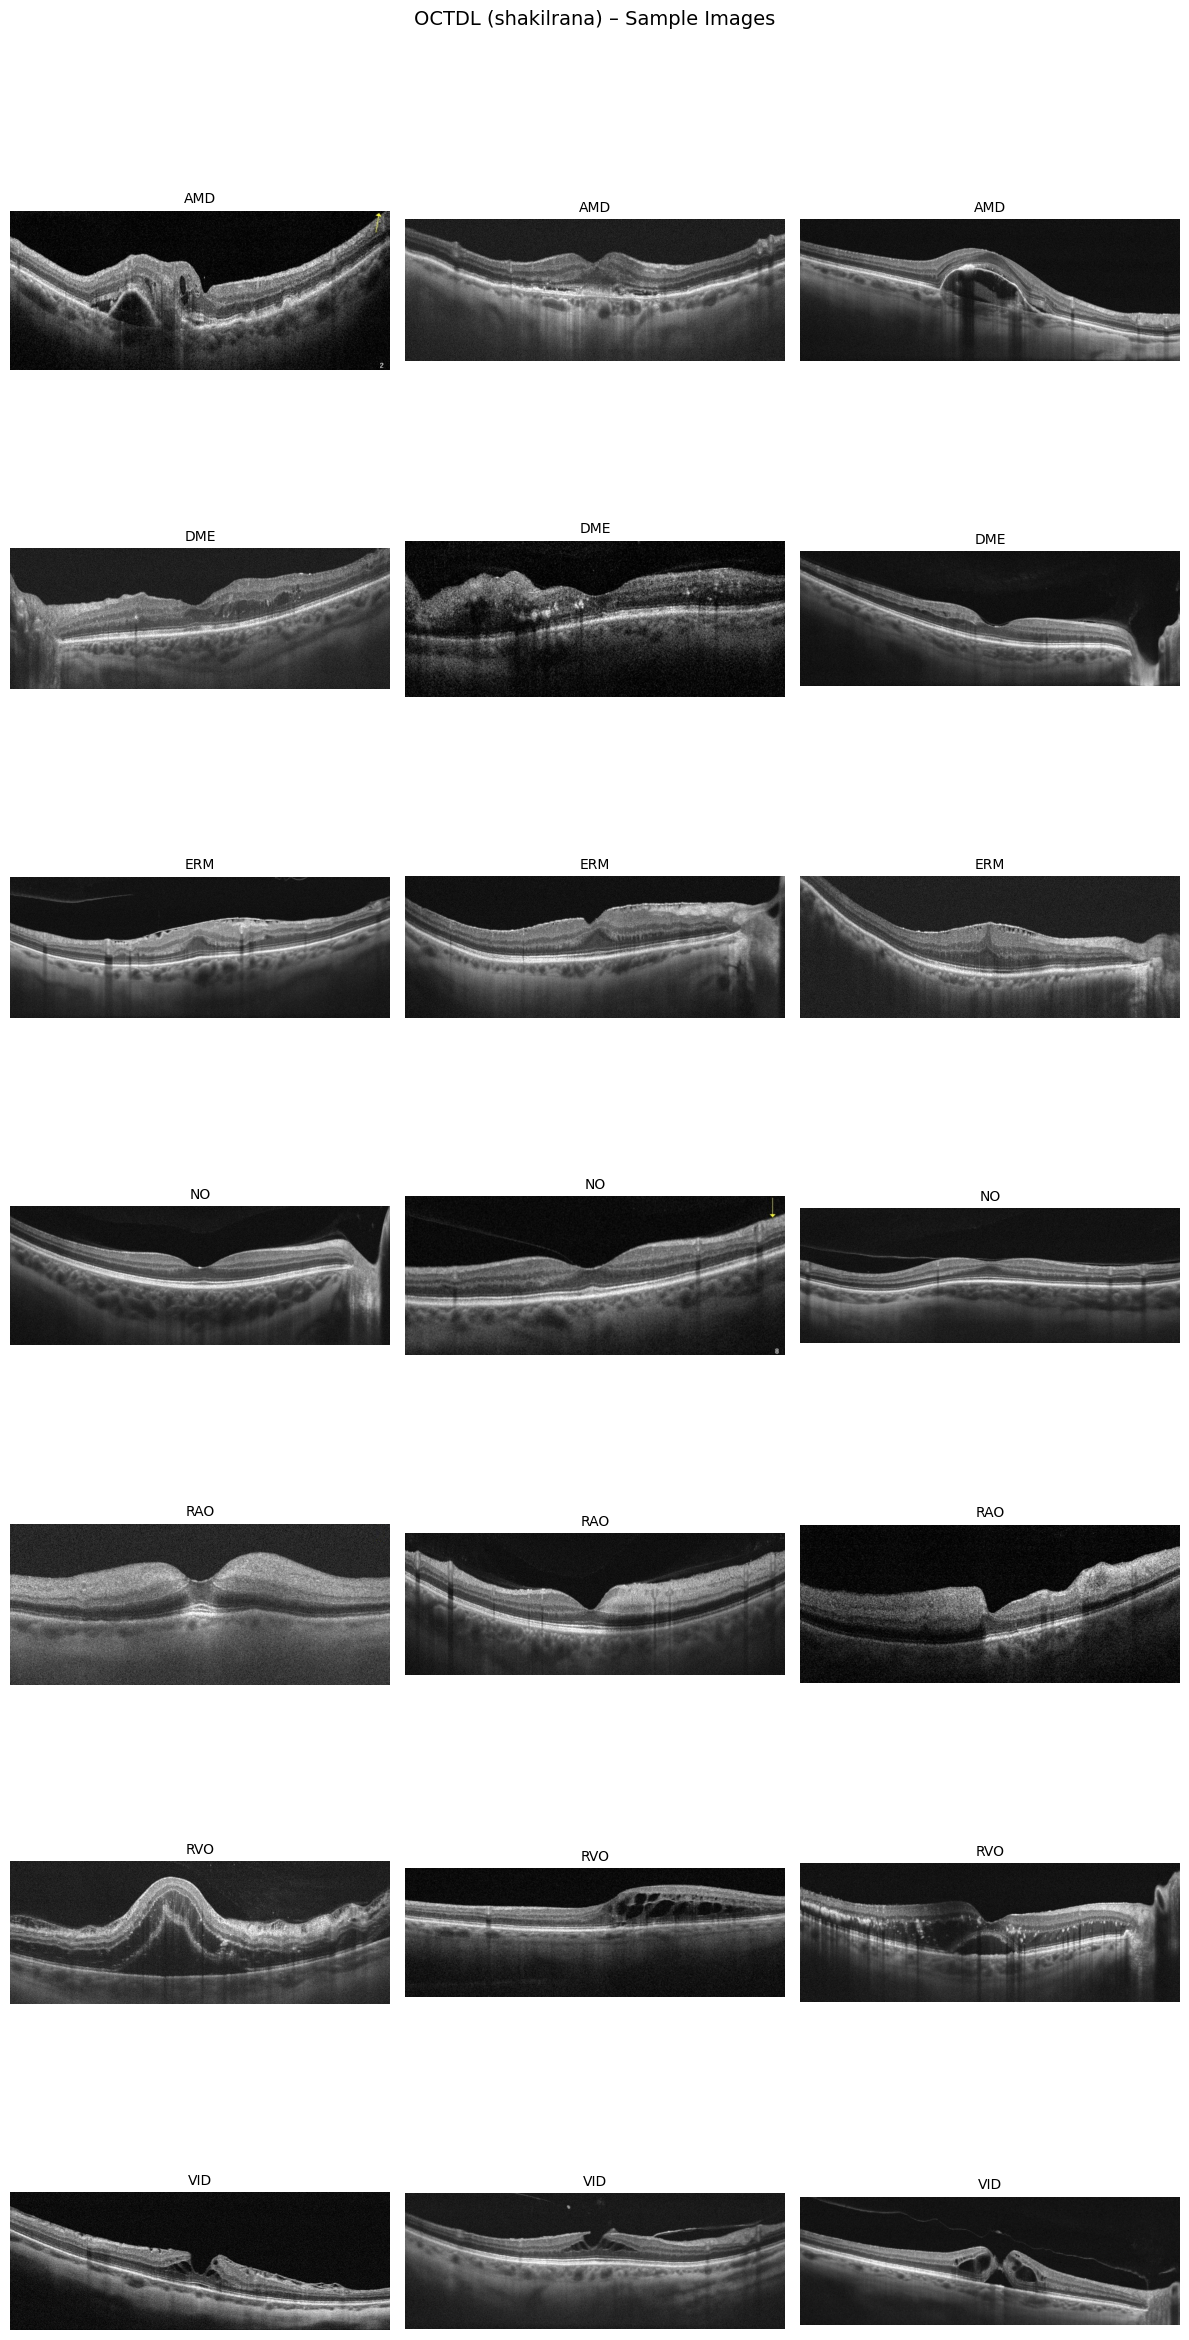


----- IMAGE STATISTICAL ANALYSIS -----
Total Images Analyzed               : 500
Unique Resolutions                  : 179
Width  – min / mean / max           : 444 / 911 / 1162
Height – min / mean / max           : 200 / 334 / 710
File Size (MB) – min / mean / max   : 0.049 / 0.205 / 0.543
Channels (most common)              : 3




In [4]:
# 1. OCTDL (shakilrana) – recommended
analyze_dataset(
    dataset_name = "OCTDL (shakilrana)",
    root_path    = "/kaggle/input/datasets/shakilrana/octdl-retinal-oct-images-dataset/OCTDL Optical Coherence Tomography Dataset for Image-Based Deep Learning Methods/OCTDL/OCTDL",
    class_folders = ["AMD", "DME", "ERM", "NO", "RAO", "RVO", "VID"]
)

DATASET: OCTDL (deepakraje)
Class folders found: ['AMD', 'DME', 'ERM', 'NO', 'RAO', 'RVO', 'VID']


----- SUMMARY TABLE -----


,Class,Image Count,Percentage,Resolution(s),Avg Size (MB)
0,AMD,1231,59.6%,"1020x418, 1020x530, 1020x538, 1020x710, 1092x4...",0.204
1,DME,147,7.1%,"1095x409, 1096x409, 1097x411, 1098x409, 1099x4...",0.181
2,ERM,155,7.5%,"1020x562, 1093x408, 1094x401, 1094x409, 1094x4...",0.172
3,NO,332,16.1%,"1020x536, 1097x407, 1098x409, 1099x409, 1099x4...",0.153
4,RAO,22,1.1%,"1098x409, 1100x409, 1100x411, 1100x412, 1101x4...",0.191
5,RVO,101,4.9%,"1094x403, 1098x409, 1098x411, 1099x409, 1099x4...",0.168
6,VID,76,3.7%,"1014x390, 1101x407, 1101x410, 1101x411, 1101x4...",0.164
7,TOTAL,2064,100%,-,0.188



----- SAMPLE IMAGES PER CLASS -----


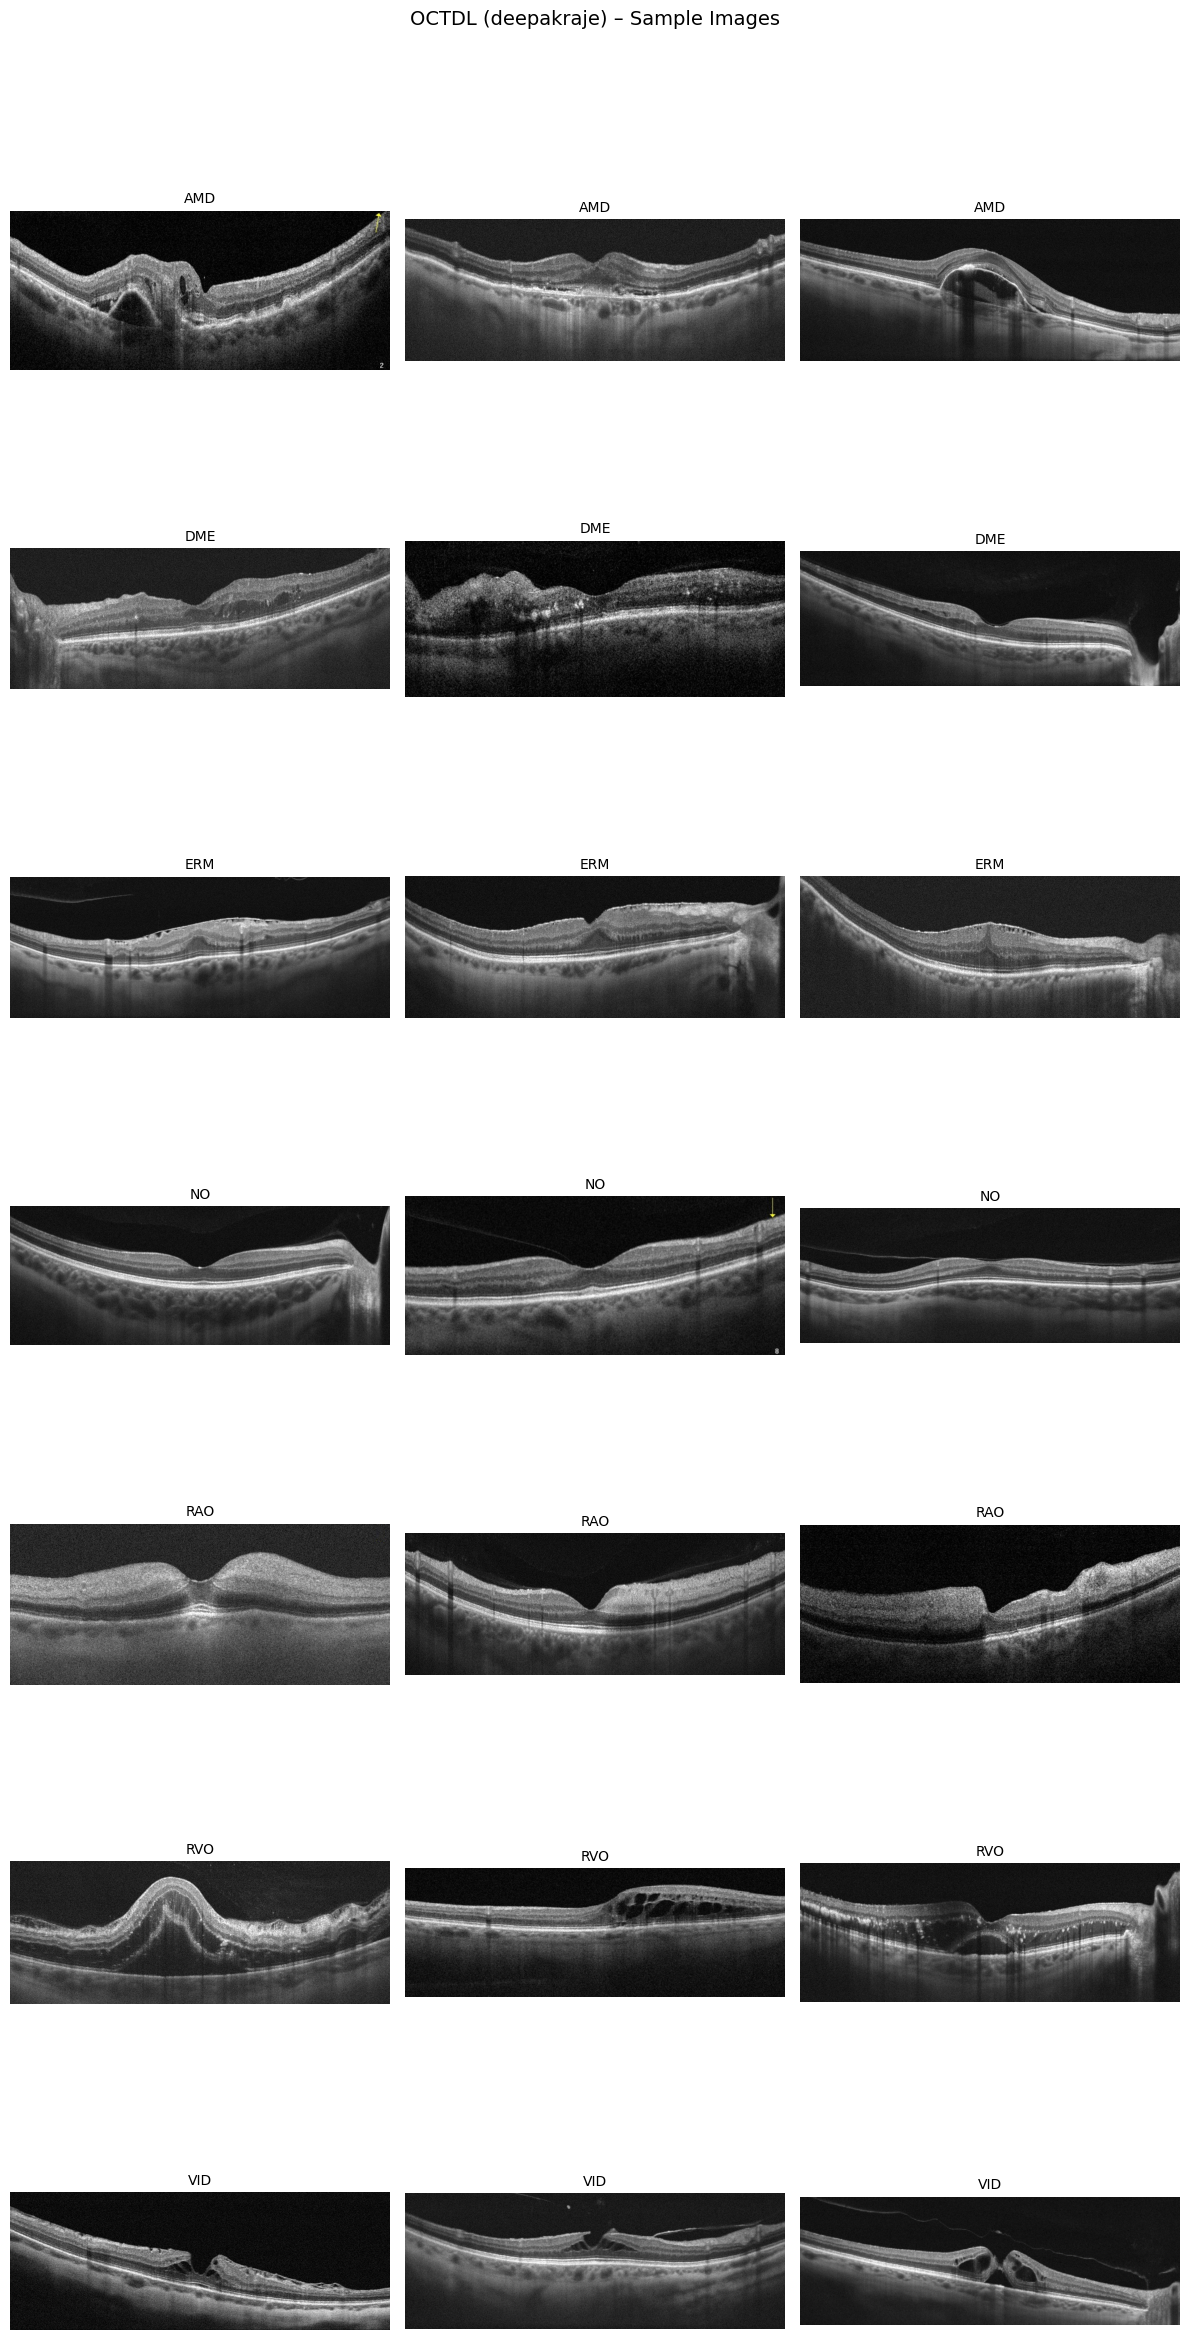


----- IMAGE STATISTICAL ANALYSIS -----
Total Images Analyzed               : 500
Unique Resolutions                  : 179
Width  – min / mean / max           : 444 / 911 / 1162
Height – min / mean / max           : 200 / 334 / 710
File Size (MB) – min / mean / max   : 0.049 / 0.205 / 0.543
Channels (most common)              : 3




In [5]:
# 2. OCTDL (deepakraje) – same data
analyze_dataset(
    dataset_name = "OCTDL (deepakraje)",
    root_path    = "/kaggle/input/datasets/deepakraje/macular-oct-data/OCTDL Optical Coherence Tomography Dataset for Image-Based Deep Learning Methods/OCTDL/OCTDL",
    class_folders = ["AMD", "DME", "ERM", "NO", "RAO", "RVO", "VID"]
)

In [6]:
import json
import pandas as pd
from pathlib import Path
from datetime import datetime
from IPython.display import display

# ============================================================
# 1. PATHS DATABASE
# ============================================================
paths_db = {
    "group": "oct-retinal",
    "created": datetime.now().isoformat(),
    "datasets": {
        "OCTDL (shakilrana)": {
            "kaggle_slug": "shakilrana/octdl-retinal-oct-images-dataset",
            "root": "/kaggle/input/datasets/shakilrana/octdl-retinal-oct-images-dataset/OCTDL Optical Coherence Tomography Dataset for Image-Based Deep Learning Methods",
            "images_folder": "/kaggle/input/datasets/shakilrana/octdl-retinal-oct-images-dataset/OCTDL Optical Coherence Tomography Dataset for Image-Based Deep Learning Methods/OCTDL/OCTDL",
            "csv": "/kaggle/input/datasets/shakilrana/octdl-retinal-oct-images-dataset/OCTDL Optical Coherence Tomography Dataset for Image-Based Deep Learning Methods/OCTDL_labels.csv",
            "type": "folder_based + csv",
            "classes": ["AMD", "DME", "ERM", "NO", "RAO", "RVO", "VID"],
            "notes": "Official OCTDL – 7 classes"
        },
        "OCTDL (deepakraje)": {
            "kaggle_slug": "deepakraje/macular-oct-data",
            "root": "/kaggle/input/datasets/deepakraje/macular-oct-data/OCTDL Optical Coherence Tomography Dataset for Image-Based Deep Learning Methods",
            "images_folder": "/kaggle/input/datasets/deepakraje/macular-oct-data/OCTDL Optical Coherence Tomography Dataset for Image-Based Deep Learning Methods/OCTDL/OCTDL",
            "csv": "/kaggle/input/datasets/deepakraje/macular-oct-data/OCTDL Optical Coherence Tomography Dataset for Image-Based Deep Learning Methods/OCTDL_labels.csv",
            "type": "folder_based + csv",
            "classes": ["AMD", "DME", "ERM", "NO", "RAO", "RVO", "VID"],
            "notes": "Same OCTDL dataset (mirror upload)"
        }
    }
}

# ============================================================
# 2. SUMMARY LOGS DB
# (Fill after analyzing)
# ============================================================
summary_db = {
    "group": "oct-retinal",
    "created": datetime.now().isoformat(),
    "results": {
        # Example – replace with real numbers
        # "OCTDL (shakilrana)": {
        #     "total_images": 2000,
        #     "classes": {"AMD": 300, "DME": 250, ...},
        #     "resolution": "496x512",
        #     "avg_size_mb": 0.08
        # }
    }
}

# ============================================================
# 3. MASTER TABLE + SIZE + TOTALS
# ============================================================
def get_folder_size_mb(folder_path: str) -> float:
    total = 0
    path = Path(folder_path)
    if not path.exists():
        return 0.0
    for f in path.rglob("*"):
        if f.is_file():
            total += f.stat().st_size
    return total / (1024 * 1024)

master_rows = []

for name, info in paths_db["datasets"].items():
    images_folder = info.get("images_folder") or info.get("root")
    size_mb = get_folder_size_mb(images_folder)
    result = summary_db["results"].get(name, {})
    
    master_rows.append({
        "Dataset": name,
        "Kaggle_Slug": info["kaggle_slug"],
        "Type": info["type"],
        "Num_Classes": len(info["classes"]),
        "Total_Images": result.get("total_images", 0),
        "Resolution": result.get("resolution", ""),
        "Avg_Size_MB": result.get("avg_size_mb", 0),
        "Total_Size_MB": round(size_mb, 1),
        "Total_Size_GB": round(size_mb / 1024, 2),
        "Classes": " | ".join(info["classes"]),
        "Per_Class_Counts": " | ".join(
            f"{cls}:{cnt}" for cls, cnt in result.get("classes", {}).items()
        ),
        "Root_Path": info["root"],
        "Images_Folder": images_folder,
        "CSV_Path": info.get("csv", ""),
        "Notes": info.get("notes", "")
    })

df_master = pd.DataFrame(master_rows)

# Grand Totals
total_images = df_master["Total_Images"].sum()
total_size_mb = df_master["Total_Size_MB"].sum()
total_size_gb = total_size_mb / 1024

print("=" * 80)
print("MASTER SUMMARY TABLE – oct-retinal")
print("=" * 80)
display(df_master[[
    "Dataset", "Num_Classes", "Total_Images", 
    "Total_Size_MB", "Total_Size_GB", "Resolution", "Avg_Size_MB"
]])

print("\n" + "=" * 80)
print("GRAND TOTALS")
print("=" * 80)
print(f"Total Datasets     : {len(df_master)}")
print(f"Total Images       : {total_images:,}")
print(f"Total Size         : {total_size_mb:,.1f} MB  ({total_size_gb:.2f} GB)")
print("=" * 80)

# Save
df_master.to_csv("/kaggle/working/oct-retinal_master_table.csv", index=False)

with open("/kaggle/working/oct-retinal_paths_db.json", "w") as f:
    json.dump(paths_db, f, indent=2)

with open("/kaggle/working/oct-retinal_summary_db.json", "w") as f:
    json.dump(summary_db, f, indent=2)

print("\n✅ Files saved:")
print(" - oct-retinal_paths_db.json")
print(" - oct-retinal_summary_db.json")
print(" - oct-retinal_master_table.csv")

MASTER SUMMARY TABLE – oct-retinal


,Dataset,Num_Classes,Total_Images,Total_Size_MB,Total_Size_GB,Resolution,Avg_Size_MB
0,OCTDL (shakilrana),7,0,388.3,0.38,,0
1,OCTDL (deepakraje),7,0,388.3,0.38,,0



GRAND TOTALS
Total Datasets     : 2
Total Images       : 0
Total Size         : 776.6 MB  (0.76 GB)

✅ Files saved:
 - oct-retinal_paths_db.json
 - oct-retinal_summary_db.json
 - oct-retinal_master_table.csv
